In [1]:
import numpy as np
from torch.utils.data import Dataset

class RandomImageDataset(Dataset):
    
    def __init__(self, n, image_size=(3, 224, 224), num_classes=10, 
                 transform=None, seed=None):

        self.n = n
        self.image_size = image_size
        self.num_classes = num_classes
        self.transform = transform
        
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)

        self.images = []
        self.labels = []
        
        for _ in range(n):
            # 生成随机图像数据 (值范围 0-1)
            img = np.random.rand(*image_size).astype(np.float32)
            # 生成随机标签
            label = np.random.randint(0, num_classes)
            
            self.images.append(img)
            self.labels.append(label)
    
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # 转换为torch tensor
        image = torch.from_numpy(image)
        
        # 应用变换（如果有）
        if self.transform:
            image = self.transform(image)
        
        return image, label


class LazyRandomImageDataset(Dataset):
    
    def __init__(self, n, image_size=(1, 224, 224), num_classes=10, 
                 transform=None, seed=None):
        self.n = n
        self.image_size = image_size
        self.num_classes = num_classes
        self.transform = transform
        self.seed = seed
        
        # 设置全局随机种子
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
    
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        """
        获取数据样本（惰性生成）
        """
        # 为每个样本设置确定性随机种子
        if self.seed is not None:
            # 使用基础种子 + 索引来确保可重现性
            sample_seed = self.seed + idx
            rng = np.random.RandomState(sample_seed)
        else:
            rng = np.random
        
        # 生成随机图像
        image = rng.rand(*self.image_size).astype(np.float32)
        
        # 生成随机标签
        label = rng.randint(0, self.num_classes)
        
        # 转换为torch tensor
        image = torch.from_numpy(image)
        # 应用变换
        if self.transform:
            image = self.transform(image)
        return image, label

Feature Map 1 Shape: torch.Size([1, 16, 112, 112])
Feature Map 2 Shape: torch.Size([1, 32, 56, 56])
Feature Map 3 Shape: torch.Size([1, 64, 28, 28])
Output Shape: torch.Size([1, 10])


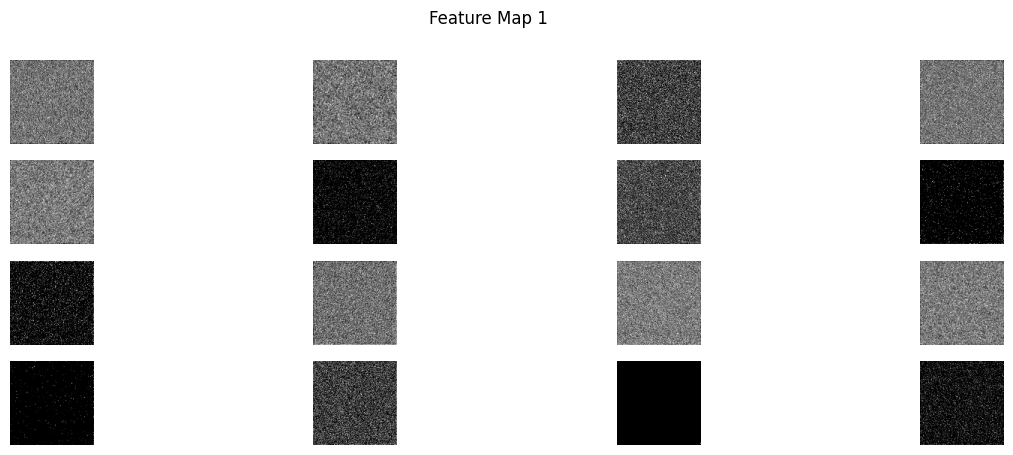

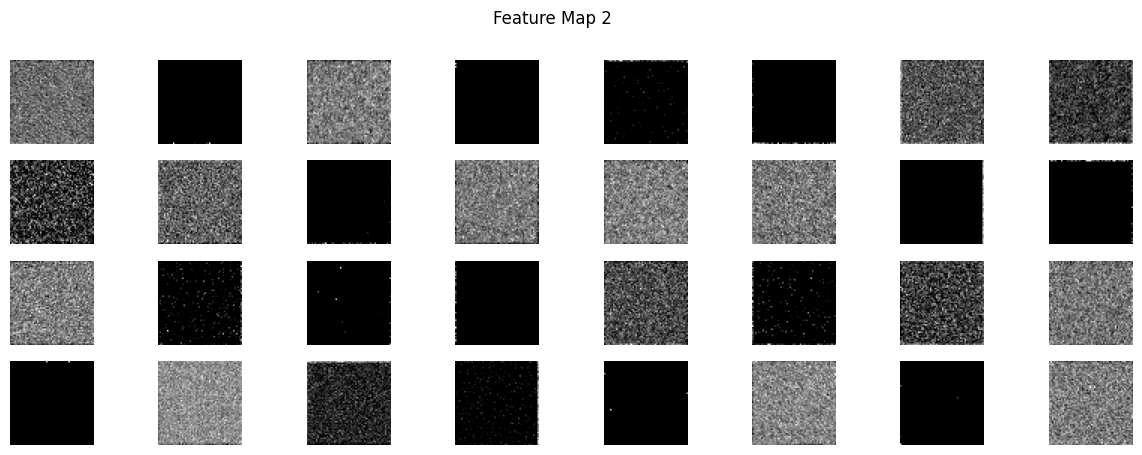

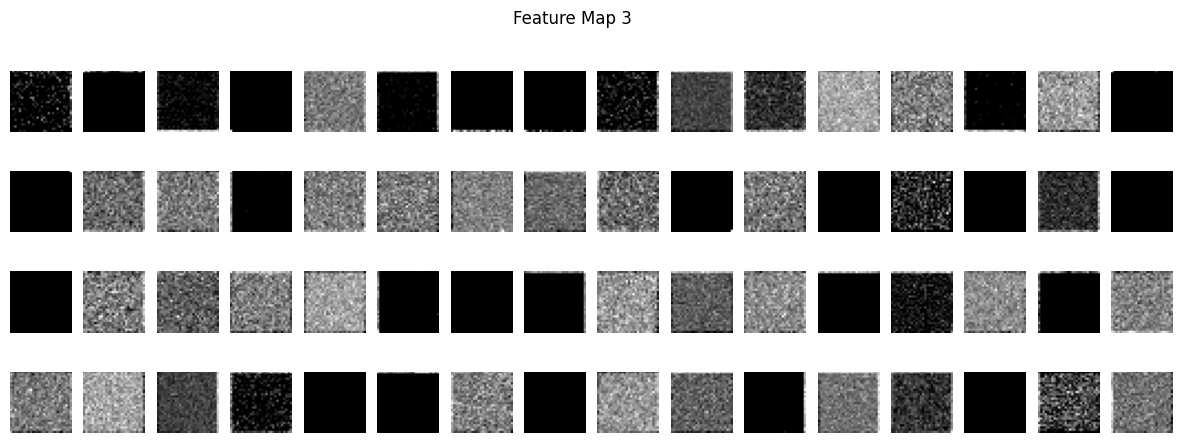

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # 定义卷积层
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  # 输入为1通道（灰度图）
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化层
        self.fc1 = nn.Linear(50176, 128)  # 全连接层
        self.fc2 = nn.Linear(128, num_classes)  # 输出层

    def forward(self, x):
        # CNN 部分
        x = self.pool(F.relu(self.conv1(x)))  # [batch_size, 16, 28, 28]
        feature_map1 = x  # 保存第一层特征图
        x = self.pool(F.relu(self.conv2(x)))  # [batch_size, 32, 14, 14]
        feature_map2 = x  # 保存第二层特征图
        x = self.pool(F.relu(self.conv3(x)))  # [batch_size, 64, 7, 7]
        feature_map3 = x  # 保存第三层特征图

        # 展平特征图并通过全连接层
        x = x.view(x.size(0), -1)  # [batch_size, 64 * 7 * 7]
        x = F.relu(self.fc1(x))  # [batch_size, 128]
        x = self.fc2(x)  # [batch_size, num_classes]

        return feature_map1, feature_map2, feature_map3, x  # 返回特征图和最终输出

# 测试模型
if __name__ == '__main__':
    # 定义数据预处理
    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ])

    # 加载 MNIST 数据集
    dataset = RandomImageDataset(5)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

    # 创建模型实例
    model = SimpleCNN()

    # 获取一张图片
    for images, labels in dataloader:
        feature_map1, feature_map2, feature_map3, output = model(images)

        # 打印特征图的形状
        print("Feature Map 1 Shape:", feature_map1.shape)  # 第一层特征图
        print("Feature Map 2 Shape:", feature_map2.shape)  # 第二层特征图
        print("Feature Map 3 Shape:", feature_map3.shape)  # 第三层特征图
        print("Output Shape:", output.shape)  # 输出的形状

        # 可视化特征图
        # 可视化第一层特征图
        feature_map1 = feature_map1.detach().cpu().numpy()[0]  # 转换为 NumPy 数组
        plt.figure(figsize=(32,8))
        for i in range(feature_map1.shape[0]):
            plt.subplot(4, 4, i + 1)
            plt.imshow(feature_map1[i], cmap='hot')
            plt.axis('off')
        plt.suptitle('Feature Map 1')
        plt.show()

        # 可视化第二层特征图
        feature_map2 = feature_map2.detach().cpu().numpy()[0]
        plt.figure(figsize=(32,8))
        for i in range(feature_map2.shape[0]):
            plt.subplot(4, 8, i + 1)
            plt.imshow(feature_map2[i], cmap='hot')
            plt.axis('off')
        plt.suptitle('Feature Map 2')
        plt.show()

        # 可视化第三层特征图
        feature_map3 = feature_map3.detach().cpu().numpy()[0]
        plt.figure(figsize=(32,8))
        for i in range(feature_map3.shape[0]):
            plt.subplot(4, 16, i + 1)
            plt.imshow(feature_map3[i], cmap='hot')
            plt.axis('off')
        plt.suptitle('Feature Map 3')
        plt.show()

        break  # 只处理一张图片


In [33]:
from data import DataLoaderVal
from torch.utils.data import DataLoader
from PIL import Image
from model import MyNet2_2

model = MyNet2_2(base_channels=16, num_block=3)
checkpoint = torch.load('checkpoints/DeFlare/models/model_bestPSNR_REAL.pth',weights_only=False)
model.load_state_dict(checkpoint["state_dict"])

real_val_dataset = DataLoaderVal('dataset/Flare7Kpp/test_data/real',{'patch_size':512})
real_val_loader = DataLoader(dataset=real_val_dataset, batch_size=1, shuffle=False, num_workers=1,
                                 drop_last=True)
for ii, data_val in enumerate(real_val_loader, 0):
    if ii==6:
        x = data_val[1]
        features = model.getFeatureMaps(x)
        print(features)
        break



{'proj_in': tensor([[[[-0.0233,  0.0150,  0.0159,  ...,  0.0228,  0.0240, -0.0222],
          [ 0.0363,  0.0357,  0.0355,  ...,  0.0426,  0.0426, -0.0164],
          [ 0.0350,  0.0345,  0.0354,  ...,  0.0436,  0.0417, -0.0173],
          ...,
          [ 0.0151, -0.0117, -0.0101,  ...,  0.0152,  0.0184, -0.0308],
          [ 0.0231, -0.0142, -0.0133,  ...,  0.0137,  0.0137, -0.0347],
          [-0.0240, -0.0664, -0.0672,  ..., -0.0367, -0.0371, -0.0599]],

         [[ 0.2677,  0.3006,  0.3013,  ...,  0.3183,  0.3186,  0.2842],
          [ 0.2654,  0.3419,  0.3425,  ...,  0.3597,  0.3605,  0.3466],
          [ 0.2670,  0.3411,  0.3417,  ...,  0.3604,  0.3618,  0.3474],
          ...,
          [ 0.2664,  0.3285,  0.3272,  ...,  0.3013,  0.3022,  0.2971],
          [ 0.2665,  0.3333,  0.3341,  ...,  0.2951,  0.2973,  0.2960],
          [ 0.2236,  0.2735,  0.2727,  ...,  0.2486,  0.2512,  0.2611]],

         [[-0.1804, -0.1810, -0.1813,  ..., -0.1900, -0.1886, -0.1677],
          [-0.1722

In [73]:
sk1,sk2,sk3,[pred,flare] = features['out_reduce_-3'],features['out_reduce_-2'],features['out_reduce_-1'],torch.chunk(features['projout'],2,dim=1)

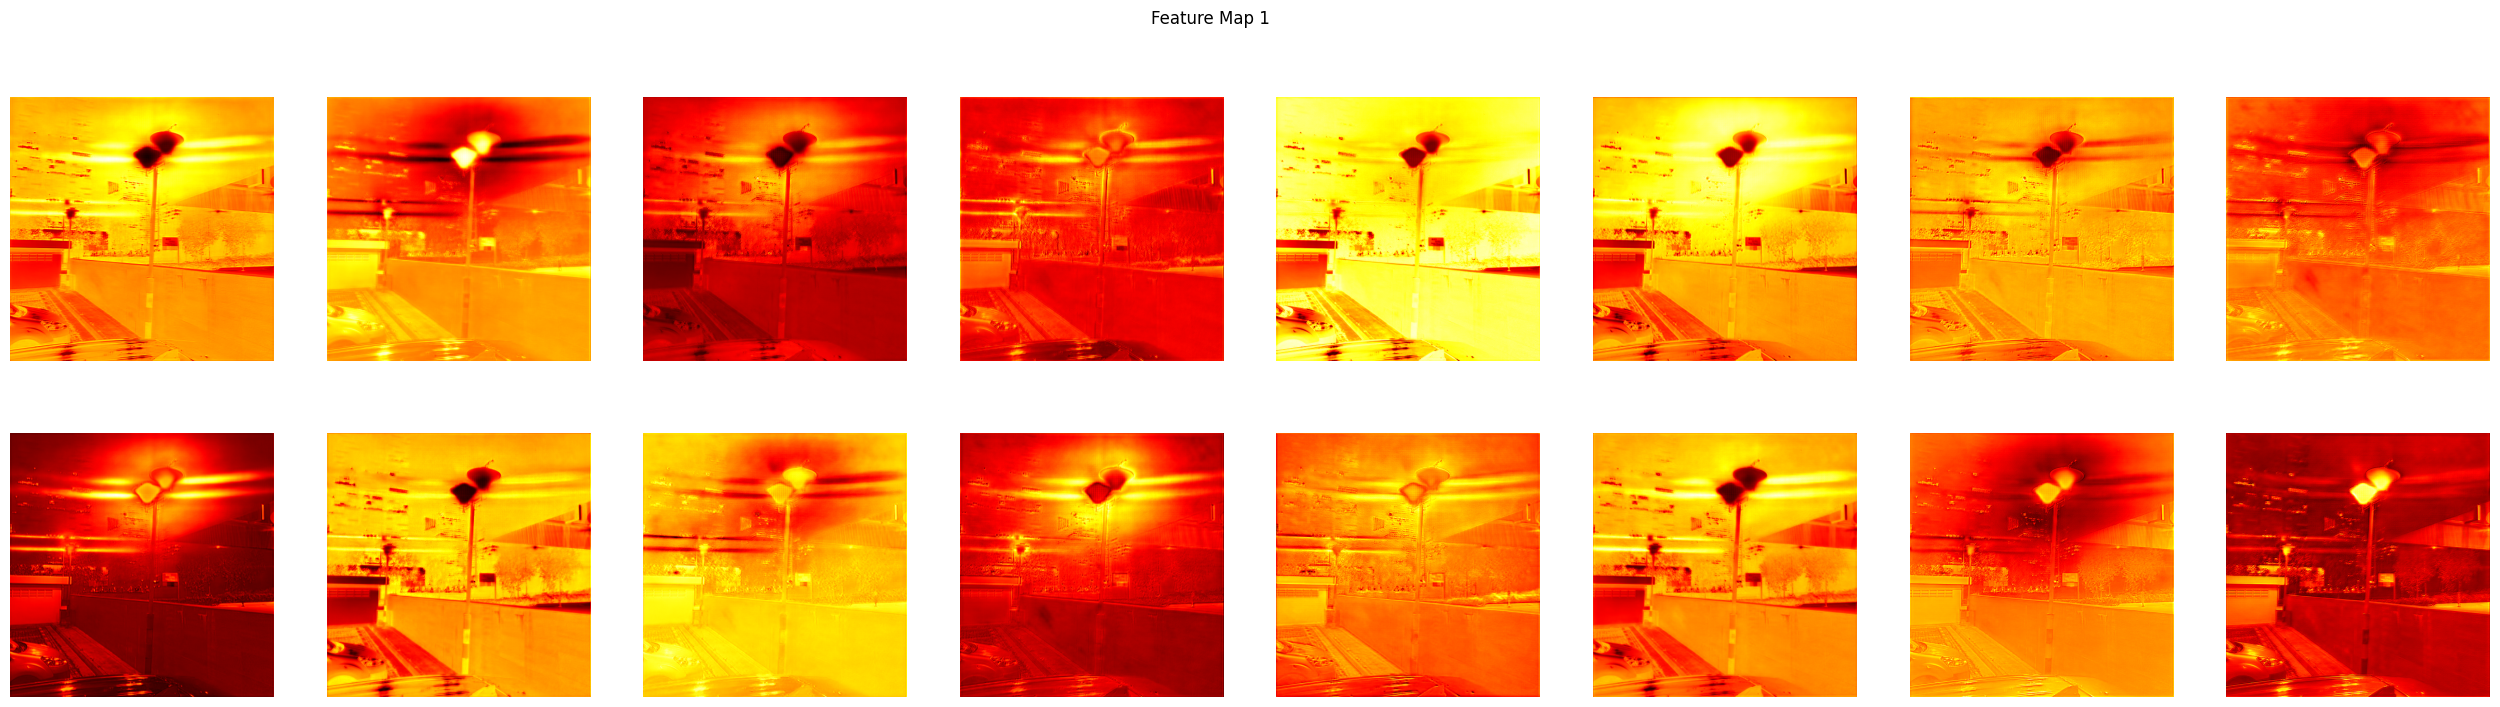

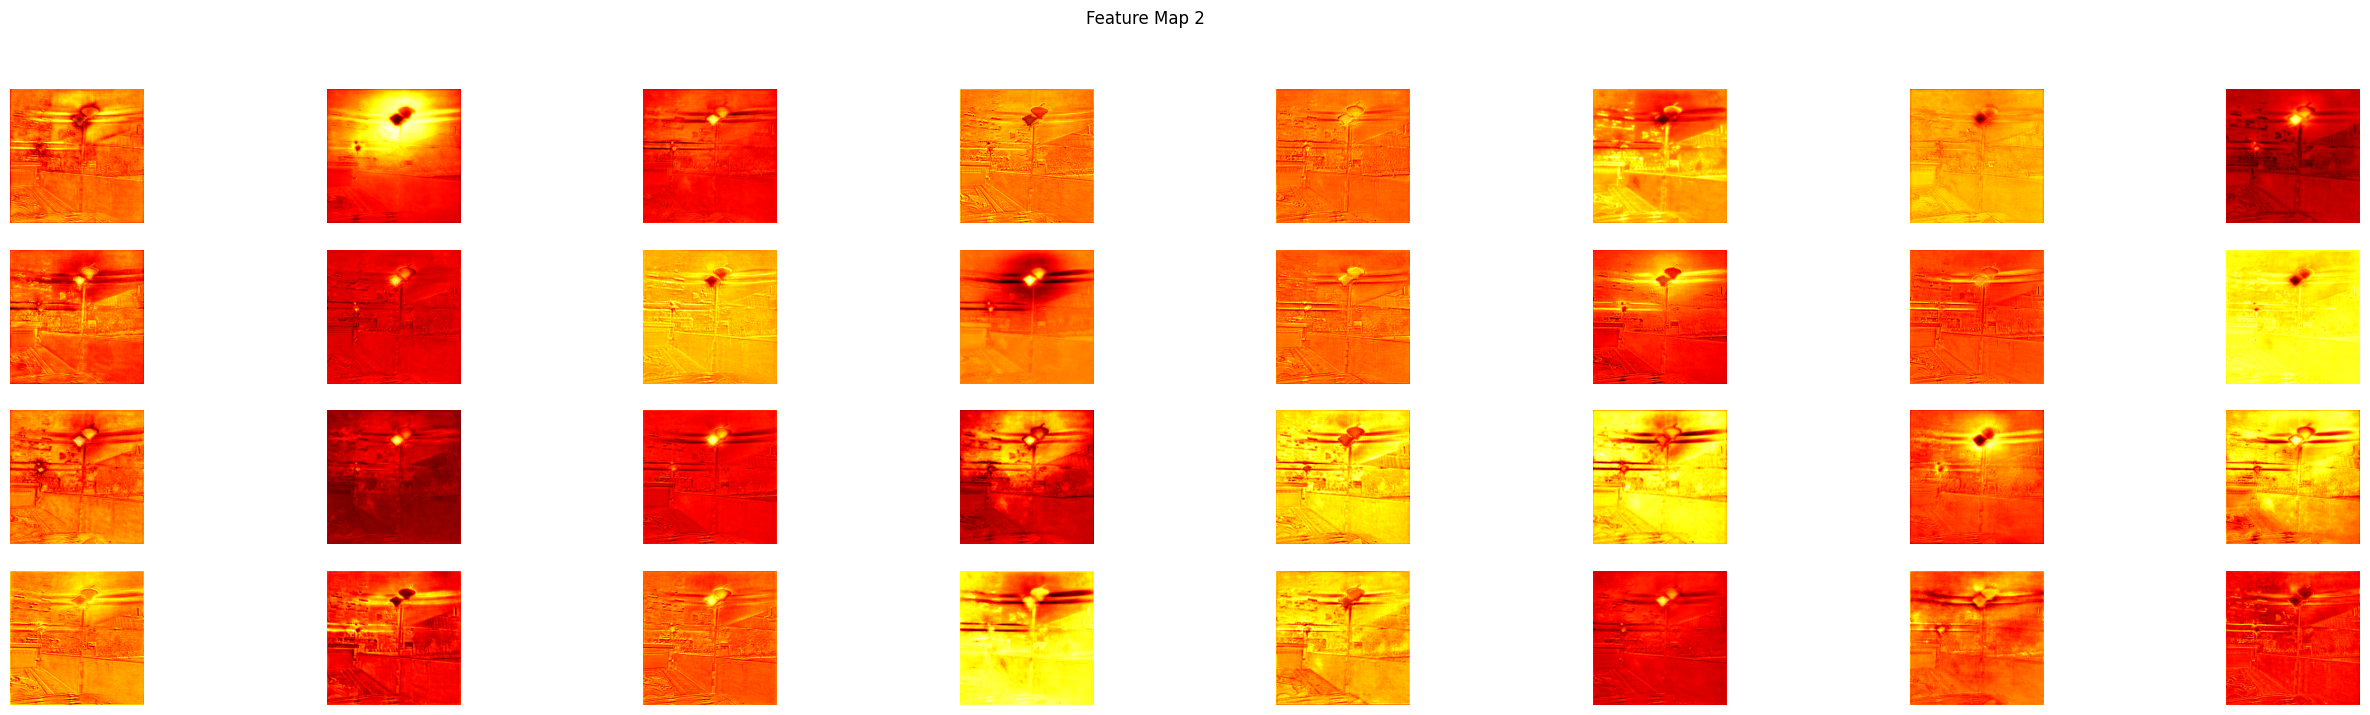

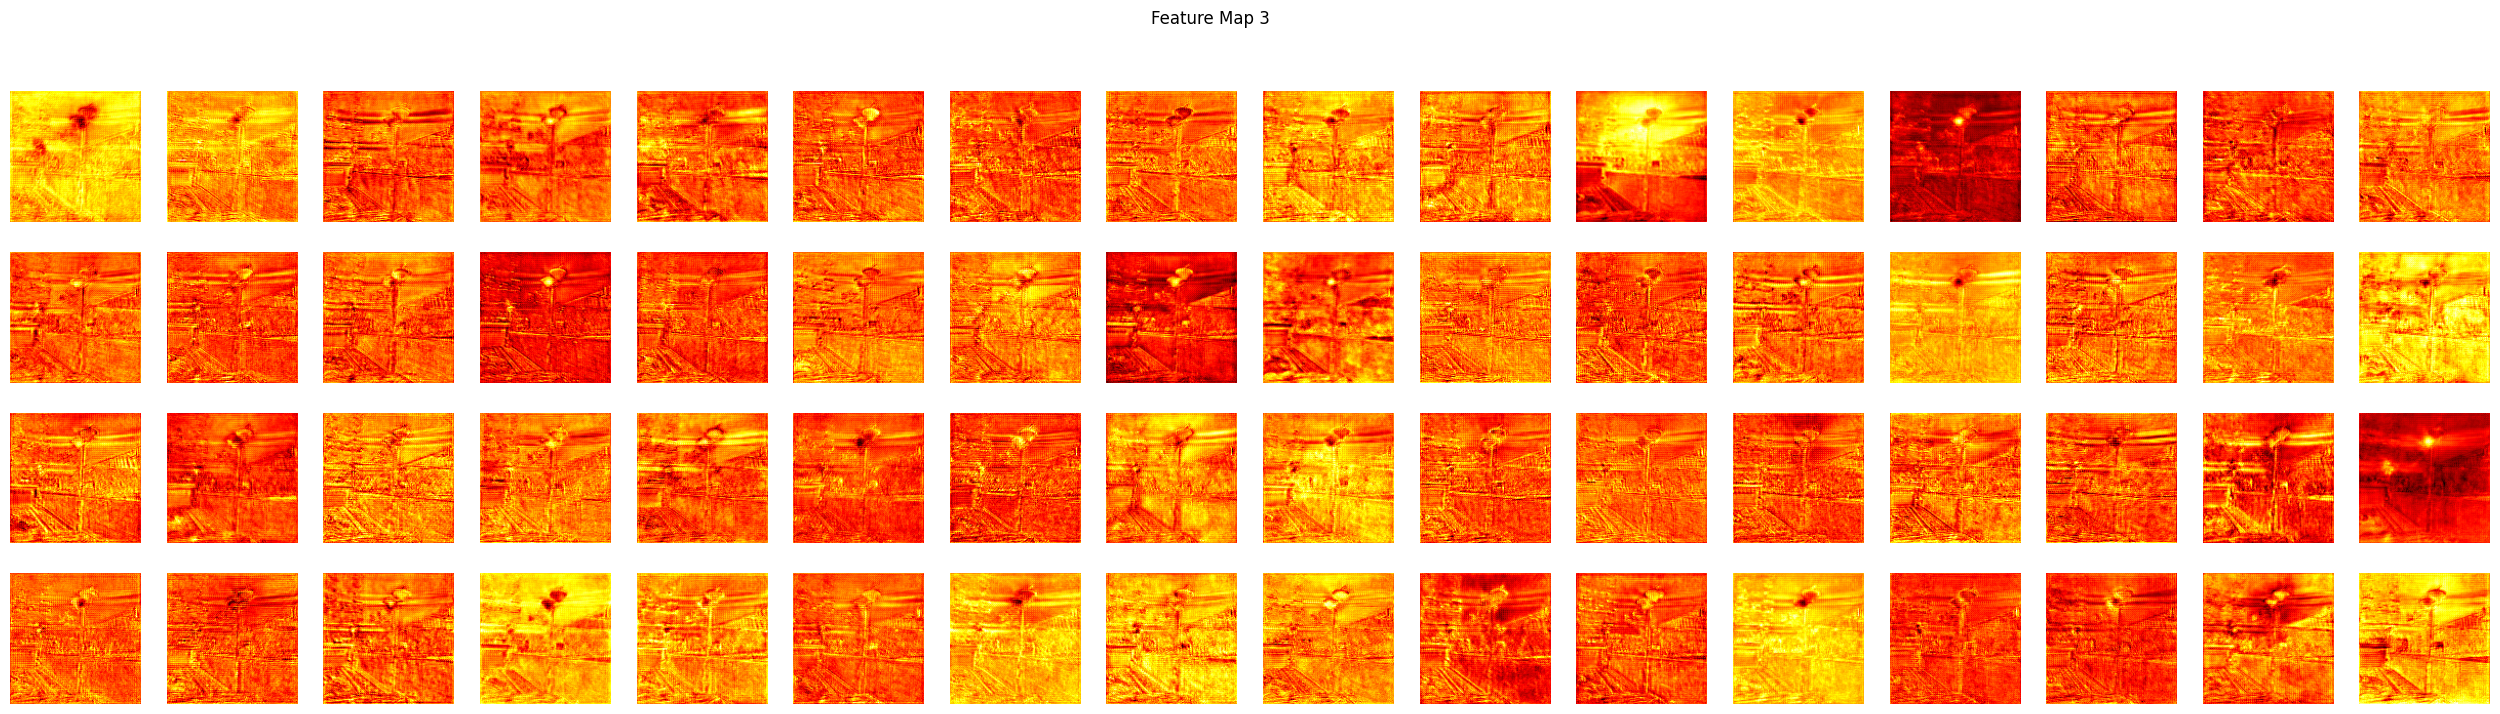

<Figure size 1500x500 with 0 Axes>

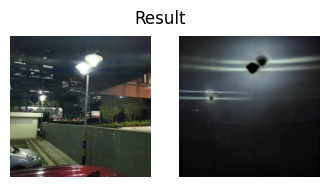

In [84]:
feature_map1 = sk1.detach().cpu().numpy()[0]  # 转换为 NumPy 数组
plt.figure(figsize=(32,8))
for i in range(feature_map1.shape[0]):
    plt.subplot(2, 8, i + 1)
    plt.imshow(feature_map1[i], cmap='hot')
    plt.axis('off')
plt.suptitle('Feature Map 1')
plt.show()

# 可视化第二层特征图
feature_map2 = sk2.detach().cpu().numpy()[0]
plt.figure(figsize=(32, 8))
for i in range(feature_map2.shape[0]):
    plt.subplot(4, 8, i + 1)
    plt.imshow(feature_map2[i], cmap='hot')
    plt.axis('off')
plt.suptitle('Feature Map 2')
plt.show()

# 可视化第三层特征图
feature_map3 = sk3.detach().cpu().numpy()[0]
plt.figure(figsize=(32,8))
for i in range(feature_map3.shape[0]):
    plt.subplot(4, 16, i + 1)
    plt.imshow(feature_map3[i], cmap='hot')
    plt.axis('off')
plt.suptitle('Feature Map 3')
plt.show()

plt.figure(figsize=(15,5))
pred1 = torch.clamp(x+pred,0,1)
pred1 = pred1.detach().cpu().numpy()[0].transpose((1,2,0))
plt.figure(figsize=(4,2))
plt.subplot(1, 2, 1)
plt.imshow(pred1)
plt.axis('off')
flare1 = torch.clamp(x+flare,0,1)
flare1 = flare1.detach().cpu().numpy()[0] .transpose((1,2,0))
plt.subplot(1, 2, 2)
plt.imshow(flare1)
plt.axis('off')
plt.suptitle('Result')
plt.show()


In [78]:
!python -v

^C
